In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = r'C:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\project_4\cnn\classification_dataset\train'
valid_dir = r'C:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\project_4\cnn\classification_dataset\valid'
test_dir = r'C:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\project_4\cnn\classification_dataset\test'

In [5]:

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)


In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [10]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,     # remove the original classifier head
    weights='imagenet'     # load pretrained weights
)


In [11]:
base_model.trainable = False


In [12]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)   # binary classification

model = Model(inputs=base_model.input, outputs=output)


In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
""" history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)
 """

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.5766 - loss: 0.7498 - val_accuracy: 0.6787 - val_loss: 0.6033
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 56s 669ms/step - accuracy: 0.7250 - loss: 0.5473 - val_accuracy: 0.8032 - val_loss: 0.4543
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 655ms/step - accuracy: 0.8171 - loss: 0.4247 - val_accuracy: 0.8620 - val_loss: 0.3655
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 56s 666ms/step - accuracy: 0.8711 - loss: 0.3473 - val_accuracy: 0.8891 - val_loss: 0.3083
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 624ms/step - accuracy: 0.8896 - loss: 0.3058 - val_accuracy: 0.9118 - val_loss: 0.2687
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 641ms/step - accuracy: 0.8967 - loss: 0.2714 - val_accuracy: 0.9231 - val_loss: 0.2395
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 634ms/step - accuracy: 0.9125 - loss: 0.2504 - val_accuracy: 0.9389 - val_loss: 0.2171
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 642ms/step - accuracy: 0.9279 - loss: 0.2160 - val_accura

In [15]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 478ms/step - accuracy: 0.9581 - loss: 0.1480
Test Accuracy: 0.9581395387649536
Test Loss: 0.1480313092470169


In [16]:
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype("int32")

from sklearn.metrics import classification_report
target_names = list(test_data.class_indices.keys())

print(classification_report(test_data.classes, y_pred_classes, target_names=target_names))


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 654ms/step
              precision    recall  f1-score   support

        bird       0.96      0.97      0.96       121
       drone       0.96      0.95      0.95        94

    accuracy                           0.96       215
   macro avg       0.96      0.96      0.96       215
weighted avg       0.96      0.96      0.96       215



In [ ]:
""" mobilenet_v2: 

              precision    recall  f1-score   support

        bird       0.96      0.97      0.96       121
       drone       0.96      0.95      0.95        94

    accuracy                           0.96       215
   macro avg       0.96      0.96      0.96       215
weighted avg       0.96      0.96      0.96       215 """

In [ ]:
""" model.save("transfer_mobilenetv2_model_01.h5")
 """

Text(0.5, 1.0, 'Confusion Matrix')

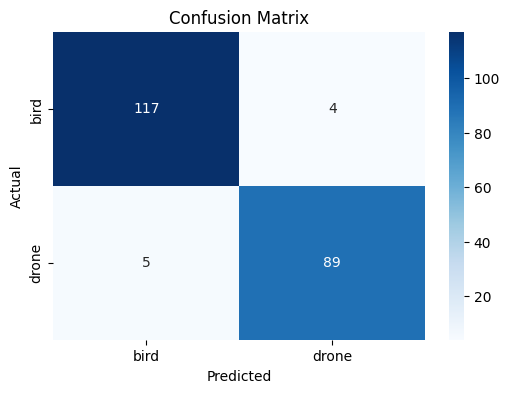

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(test_data.classes, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [12]:
# now lets try another pretrained model - efficientnetb0

In [29]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [16]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [17]:
from tensorflow.keras.applications import EfficientNetB0

In [18]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


In [19]:
base_model.trainable = False


In [20]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)   # Prevent overfitting
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


In [21]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [23]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 73s 866ms/step - accuracy: 0.7265 - loss: 0.5792 - val_accuracy: 0.8371 - val_loss: 0.5184
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 824ms/step - accuracy: 0.7787 - loss: 0.5245 - val_accuracy: 0.9005 - val_loss: 0.4554
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 822ms/step - accuracy: 0.8486 - loss: 0.4625 - val_accuracy: 0.9276 - val_loss: 0.4043
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 832ms/step - accuracy: 0.8734 - loss: 0.4176 - val_accuracy: 0.9502 - val_loss: 0.3640
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 826ms/step - accuracy: 0.8971 - loss: 0.3831 - val_accuracy: 0.9570 - val_loss: 0.3307
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 822ms/step - accuracy: 0.9091 - loss: 0.3563 - val_accuracy: 0.9593 - val_loss: 0.3036
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 828ms/step - accuracy: 0.9166 - loss: 0.3269 - val_accuracy: 0.9661 - val_loss: 0.2810
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 826ms/step - accuracy: 0.9230 - loss: 0.3116 - val_accu

In [24]:
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

from sklearn.metrics import classification_report
print(classification_report(test_data.classes, y_pred_classes, target_names=['bird','drone']))


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 
              precision    recall  f1-score   support

        bird       0.95      0.98      0.96       121
       drone       0.97      0.94      0.95        94

    accuracy                           0.96       215
   macro avg       0.96      0.96      0.96       215
weighted avg       0.96      0.96      0.96       215



In [ ]:
""" efficientnetb0:

               precision    recall  f1-score   support

        bird       0.95      0.98      0.96       121
       drone       0.97      0.94      0.95        94

    accuracy                           0.96       215
   macro avg       0.96      0.96      0.96       215
weighted avg       0.96      0.96      0.96       215 """

In [ ]:
""" model.save("transfer_EfficientNetB0_model_01.h5") """

Text(0.5, 1.0, 'Confusion Matrix')

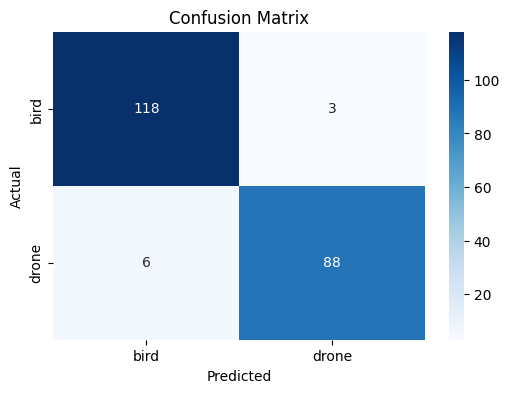

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(test_data.classes, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [27]:
# now lets try resnet50v2

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input


In [31]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [32]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [33]:
from tensorflow.keras.applications import ResNet50V2


In [34]:
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 195s 2us/step


In [35]:
base_model.trainable = False

In [36]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [38]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8956 - loss: 0.2339 - val_accuracy: 0.9502 - val_loss: 0.1225
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9602 - loss: 0.1134 - val_accuracy: 0.9593 - val_loss: 0.1024
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9658 - loss: 0.0893 - val_accuracy: 0.9615 - val_loss: 0.0941
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9651 - loss: 0.0828 - val_accuracy: 0.9661 - val_loss: 0.0841
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9778 - loss: 0.0717 - val_accuracy: 0.9615 - val_loss: 0.0869
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9733 - loss: 0.0691 - val_accuracy: 0.9615 - val_loss: 0.0850
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9745 - loss: 0.0651 - val_accuracy: 0.9593 - val_loss: 0.0855
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9782 - loss: 0.0578 - val_accuracy: 0.9661 - v

In [39]:
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

from sklearn.metrics import classification_report
print(classification_report(test_data.classes, y_pred_classes, target_names=['bird','drone']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
              precision    recall  f1-score   support

        bird       0.98      0.98      0.98       121
       drone       0.98      0.98      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



In [ ]:
""" resnet50v2: 

              precision    recall  f1-score   support

        bird       0.98      0.98      0.98       121
       drone       0.98      0.98      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215 """

In [ ]:
""" model.save("transfer_ResNet50V2_model_01.h5") """

Text(0.5, 1.0, 'Confusion Matrix')

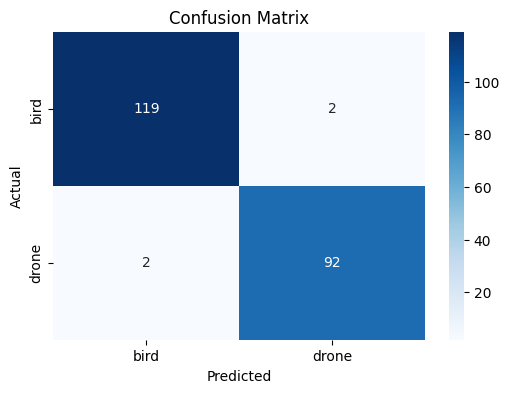

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(test_data.classes, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")